In [1]:
import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from PIL import Image
from sklearn.metrics import classification_report
import shutil
from google.colab import drive
import zipfile

In [2]:
drive.mount('/content/drive')

zip_path            = '/content/drive/MyDrive/FruitinAmazon.zip'
extracted_base_path = '/content/fruit_dataset'

Mounted at /content/drive


In [3]:
os.makedirs(extracted_base_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_base_path)

content_dirs = [
    d for d in os.listdir(extracted_base_path)
    if os.path.isdir(os.path.join(extracted_base_path, d))
]
data_dir  = os.path.join(extracted_base_path, content_dirs[0]) if len(content_dirs) == 1 else extracted_base_path
train_dir = os.path.join(data_dir, 'train')
test_dir  = os.path.join(data_dir, 'test')

print(f"Dataset root : {data_dir}")
print(f"Train folder : {train_dir}")
print(f"Test folder  : {test_dir}")
print(f"Classes      : {sorted(os.listdir(train_dir))}")

Dataset root : /content/fruit_dataset/FruitinAmazon
Train folder : /content/fruit_dataset/FruitinAmazon/train
Test folder  : /content/fruit_dataset/FruitinAmazon/test
Classes      : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Number of classes : 6
Classes           : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


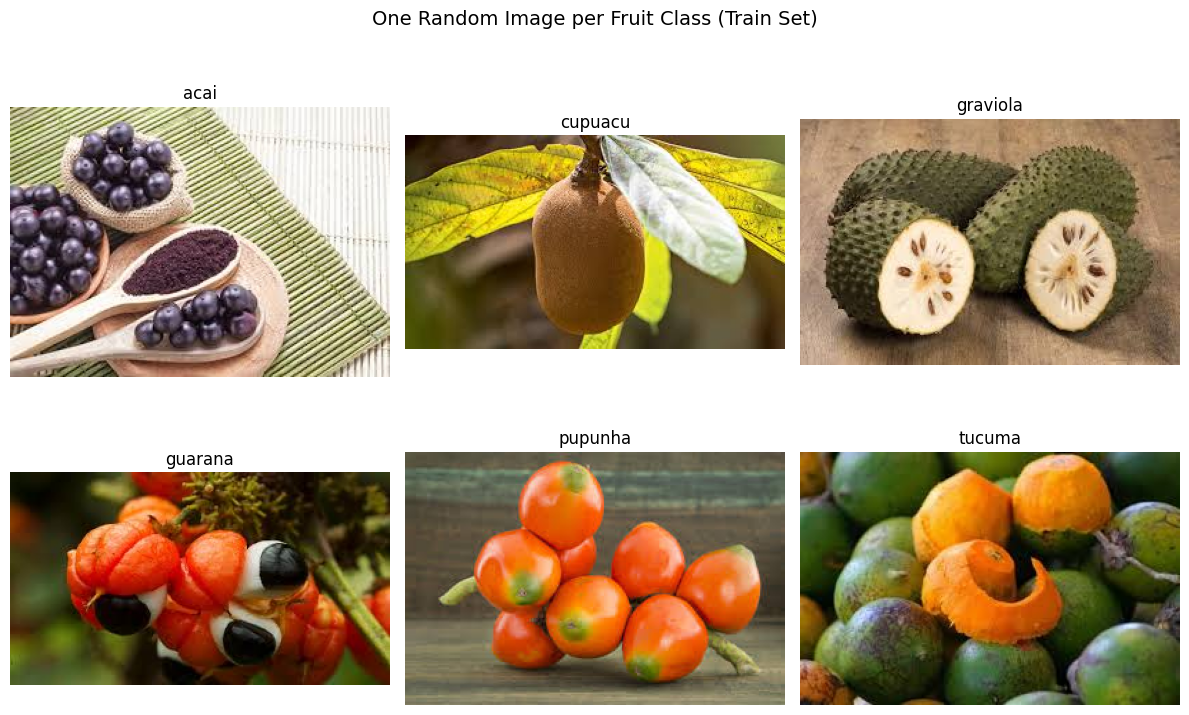

In [4]:
class_names = sorted([
    name for name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, name))
])
num_classes = len(class_names)
print(f"Number of classes : {num_classes}")
print(f"Classes           : {class_names}")

cols = (num_classes + 1) // 2
rows = 2

plt.figure(figsize=(cols * 4, rows * 4))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    files = [
        f for f in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, f))
        and f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))
    ]
    if not files:
        continue
    img = Image.open(os.path.join(class_path, random.choice(files)))
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.suptitle('One Random Image per Fruit Class (Train Set)', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
corrupted_images = []

for root, dirs, files in os.walk(train_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError):
                corrupted_images.append(file_path)

if corrupted_images:
    for img_path in corrupted_images:
        os.remove(img_path)
        print(f"Removed corrupted image: {img_path}")
else:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [6]:
img_height = 128
img_width  = 128
image_size = (img_height, img_width)
batch_size = 16

# Training dataset - full train/ folder
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=image_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

# Validation/test dataset - dedicated test/ folder (all 6 classes guaranteed)
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=image_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

class_names = train_ds.class_names
num_classes  = len(class_names)
print(f"Train classes : {class_names}")
print(f"Test classes  : {val_ds.class_names}")
print(f"Num classes   : {num_classes}")

# Normalise pixel values to [0, 1]
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y:   (normalization_layer(x), y))

Found 90 files belonging to 6 classes.
Found 30 files belonging to 6 classes.
Train classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Test classes  : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes   : 6


In [7]:
model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=(1, 1)),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Convolutional Block 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=(1, 1)),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(128, activation='relu'),           # Hidden Layer 1
    layers.Dense(64,  activation='relu'),            # Hidden Layer 2
    layers.Dense(num_classes, activation='softmax')  # Output Layer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [9]:
epochs = 250

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint_callback]
)

Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.1822 - loss: 2.2050

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 579ms/step - accuracy: 0.1889 - loss: 2.1401 - val_accuracy: 0.3667 - val_loss: 1.6614
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.3778 - loss: 1.5551 - val_accuracy: 0.3000 - val_loss: 1.5745
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.5065 - loss: 1.3417

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 330ms/step - accuracy: 0.5222 - loss: 1.2856 - val_accuracy: 0.4667 - val_loss: 1.2903
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7573 - loss: 0.9509

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step - accuracy: 0.7667 - loss: 0.9371 - val_accuracy: 0.5333 - val_loss: 1.0797
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8519 - loss: 0.6686

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - accuracy: 0.8444 - loss: 0.6177 - val_accuracy: 0.6000 - val_loss: 1.0589
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 458ms/step - accuracy: 0.8778 - loss: 0.3900 - val_accuracy: 0.5667 - val_loss: 0.9818
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9648 - loss: 0.1751

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 526ms/step - accuracy: 0.9667 - loss: 0.1697 - val_accuracy: 0.7000 - val_loss: 0.8662
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 326ms/step - accuracy: 0.9889 - loss: 0.1131 - val_accuracy: 0.6333 - val_loss: 1.3604
Epoch 9/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step - accuracy: 0.9889 - loss: 0.0790 - val_accuracy: 0.6333 - val_loss: 1.4271
Epoch 10/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.9889 - loss: 0.0363 - val_accuracy: 0.7000 - val_loss: 0.8002
Epoch 11/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - accuracy: 1.0000 - loss: 0.0231 - val_accuracy: 0.6667 - val_loss: 1.3982
Epoch 12/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 510ms/step - accuracy: 0.9444 - loss: 0.1374 - val_accuracy: 0.6000 - val_loss: 1.4675
Epoch 13/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step - accuracy: 0.9222 - loss: 0.2366 - val_accuracy: 0.6667 - val_loss: 1.2728
Epoch 14/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.9556 - loss: 0.1721 - val_accuracy: 0.6667 - val_loss

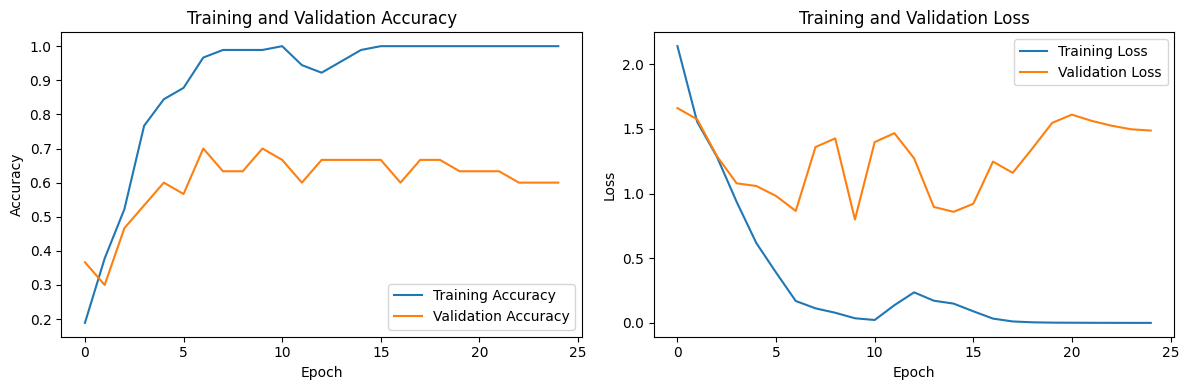

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
loss, accuracy = model.evaluate(val_ds)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7000 - loss: 0.8002
Test Loss     : 0.8002
Test Accuracy : 0.7000


In [12]:
model.save('final_image_classifier.h5')
print("Model saved to 'final_image_classifier.h5'")

loaded_model = tf.keras.models.load_model('final_image_classifier.h5')
print("Model loaded successfully.")

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)
print(f"Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_accuracy:.4f}")

Model saved to 'final_image_classifier.h5'
Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.7000 - loss: 0.8002
Loaded Model Test Loss     : 0.8002
Loaded Model Test Accuracy : 0.7000


In [13]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds            = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# zero_division=0 cleanly handles any edge-case classes with no predictions
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    zero_division=0
)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.44      0.80      0.57         5
    graviola       0.80      0.80      0.80         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.67      0.80      0.73         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.79      0.70      0.70        30
weighted avg       0.79      0.70      0.70        30

